<h1 align="center"><b>Лабораторна робота №1</b></h1>
<h3 align="right">Роботу виконав <br>студент групи ФІ-21, <br>Беркута Володимир</h3>

### Опис завдання:

Оберати на свій розсуд статтю або кейс-стаді, де описано, як математична модель, допомогла прийняти стратегнічне бізнес рішення (наприклад, прогнозування зростання бази користувачів)

### Завдання:

Підготувати звіт (1-2 ст.), відповівши на наступні питання:

* **Постановка задачі:** Яку бізнес-проблему вирішувала модель?
* **Математичні підходи:** Які методи та моделі були застосовані? (коротко, з посиланням на ключові поняття лекції)
* **Висновки:** Які загальні висновки можна зробити про ефективність застосування математичного моделювання у цьому випадку?

##### **Критерії прийняття:**

* Звіт має чітку структуру та логічний виклад.
* Всі відповіді на питання обґрунтовано, з демонстрацією розуміння підходів, розглянутих на лекції.
* Зроблені змістовні висновки щодо ефективності моделювання.

### **Звіт**

#### **Постпнова задачі** 
У сучасній індустрії відеоігор створення унікального контенту (сценаріїв, персонажів, діалогів) є найдорожчим етапом розробки. Традиційний підхід вимагає лінійної залежності: більше контенту = більше сценаристів = більший бюджет. Розробники *Middle-earth: Shadow of War* прагнули вирішити проблему масштабованості та повторюваності (replayability). Стратегічне завдання полягало у створенні системи, яка автоматично генерує персоналізовані історії для мільйонів гравців без пропорційного збільшення витрат на розробку.

#### **Класифікація системи Nemesis**

* За характером невизначеності — стохастична, ключові фактори:
    - Генерація рис характеру, титулів та зовнішності орків відбувається випадковово з величезної бази параметрів;
    - Результат подій, як-от "обман смерті" (cehat death) або зрада союзника, визначаються ймовірнісними алгоритмами, що робить досвід кожного гравця унікальним.
* За методом розв'язку — чисельна(симуляційна), оскільки система імітує поведінку великої кількості автономних агентів (орків). Ключові фактори:
    - Кожен орк має свій внутрішній стан (рівень, пам'ять, стосунки), який оновлюється незалежно;
    - Глобальний наратив (емреджність) виникає як результат множинних локальних взаємодій між агентами.
* За часовою дискретизацією — дискретна, стан системи змінюється не безперервно, а в моменти певних подій або кроків. Ключові фактори:
    - *In-between-time:* система основлює стан світу (просування в ієрархії, дуелі NPC) у відповідь на смерть гравця або швидке переміщення (fast travel);
    - Черговість кроків: певні місії Nemesis (наприклад, дуелі) мають лічильник ходів, який зменшується щоразу, коли час у грі просувається вперед.

#### Висновки

Використання математичного моделювання дозволило створити *емерджентний наратив* — складну поведінку, яка виникає з простих правил взаємодії. Ефективність підтверджується тим, що гра отримала високу оцінку за "нескінченну" кількість сюжетних ліній, що значно підвищило термін життя продукту та залученість користувачів.

### **Додаткове завдання №1** (на +1 бал)

Дати відповіді на наступні питання:
* **Практичне значення:** Які результати були отримані і як вони вплинули на бізнес-рішення? (за наявності — зазначте економічний ефект)
* **Обмеження моделі:** Які потенційні обмеження має модель і які чинники можуть вплинути на точність прогнозів?

#### Практичне занчення:
Модель довзолила отримати економічний ефект за рахунок автоматизації створення контенту, тобто кожен гравець отримує власний "ексклюзивний" сюжет. Видавництво прийняло рішення запатентувати сисетму Nemesis, визнавши її ключовим інтелектувальним активом компанії.

#### Обмеження моделі:
- Спрощення агентів: NPC можуть потврювати діалоги, якщо гравець стикається з великою кількстю орків одного типу.
- Обчислювальні витрати: Підтримка живого світу з сотнями активних агентів вимагає значних ресурсів процесора.
- Ймовірнісний ризик: занадто висока випадковість може привести до того, що гравець ніколи не зустріне "свого" Nemesis через низьку повторних зустрічей (лише 8% орків зустрічаються більше 4 разів), окрім того є ймовірність "народження" непереможного моба.

### **Додаткове завдання №2** (на +2 бали/покращення базової оцінки)

Реалізуйте моделювання обраного кейсу або статті у вигляді Python-скрипту з використанням бібліотек, таких як NumPy, SciPy та Matplotlib (або інше). Код має бути коментованим та/або містити короткий опис основних етапів моделювання.

In [1]:
import matplotlib.pyplot as plt
from scipy import stats
import networkx as nx
import numpy as np
import random

### Орк
Параметри класу:
- `name` — ім'я орка;
- `level` — рівень орка;
- `xp` — кількість досвіду;
- `memory` — пам'ять;
- `is_branded` — чи є орк помічений;
- `is_alive` — чи є орк живим (Хороший орк той, що `is_alive = False`);
- `title` — титул орка;
- `blood_brother` — кровний брат орку;
- `killed_player` — чи вбив цей орк гравця.

Методи класу:
- `add_memory()` — додати пам'ять (обмежена, до 5 подій);
- `updt_level()` — оновлення рівня до відповідної кількості досвіду.

In [2]:
class Orc:
    def __init__(self, name, level):
        self.name = name
        self.level = level
        self.xp = np.exp(self.level)
        self.memory = []
        self.is_branded = False
        self.is_alive = True
        self.title = "Grunt"
        self.blood_brother: Orc = None
        self.killed_player = False

    def add_memory(self, event):
        self.memory.append(event)
        if len(self.memory) > 5: self.memory.pop(0)
    
    def updt_level(self, deafeted_xp : float):
        self.xp += deafeted_xp
        self.level = int(np.log(self.xp))

    def __repr__(self):
        status = "Branded" if self.is_branded else "Sauron's Army"
        return f"<{self.name} (Lvl {self.level}) | {status} | Memory: {self.memory}>"

### Гравець

Параметри класу:
- `level` — рівень гравця;
- `xp` — кількість досвіду гравця.

In [3]:
class Player:
    def __init__(self, level):
        self.level: int = level
        self.xp = np.exp(level)
    
    def updt_level(self, deafeted_xp : float):
        self.xp += deafeted_xp
        self.level = int(np.log(self.xp))

### Nemesis system
Параметри класу:
- `game_progress` — прогрес гри;
- `player` — граець;
- `K` — коефіцієнт складності;
- `army` — емерджетна складова, динамічна армія;

Методи класу:
- `generate_army()` — генерує склад армії за нормальним розподілом;
- `simulate_battle()` — симуляція зіткнення гравця із обраним орком з армії;
- `create_relationships()` — випадкове створення "кровних братів";
- `simulate_internal_time()` — симуляції поєдинків між орками в середині армії;
- `show_narrative_state()` — вивід прогресу та список армії;
- `plot_army_hierarchy()` — гістограма рівнів орків у армії.

In [4]:
class NemesisNarrativeSystem:
    def __init__(self, player: Player, K: float = -.2):
        self.game_progress = 0
        self.player = player
        
        self.K = K
        self.army = []
    
    def generate_army(self, n : int = 100, max_lvl: int = 25):
        dist = np.random.normal(0, 1, n)
        lvl_dist = dist + (1 - min(dist))
        lvl_dist = (lvl_dist * max_lvl / lvl_dist.max()).astype(int)
        
        for i in range(n):
            self.army.append(Orc(f"Orc-{i}", lvl_dist[i]))
        return lvl_dist

    def simulate_battle(self, orc_index):
        orc = self.army[orc_index]
        
        # Математична модель шансу
        win_chance = 1 / (1 + np.exp(self.K * (self.player.level - orc.level)))
        
        print(f"Подія: Бій з {orc.name}. Шанс на успіх: {win_chance:.2f}")

        if random.random() < win_chance:
            # Гравець перемагає - вплив на вбудований сюжет
            print(f"Результат: Ви перемогли {orc.name}!")
            decision = random.choice(["kill", "brand"])
            
            if decision == "brand":
                orc.is_branded = True
                orc.add_memory("Player dominated me")
                orc.title = "Slave"
                print(f"Наратив: {orc.name} тепер служить вам.")
            else:
                if random.random() < 0.2:
                    orc.add_memory("I survived being killed by the Ranger")
                    orc.title = "The Survivor"
                    print(f"Наратив: {orc.name} обманув смерть!")
                else:
                    self.player.updt_level(orc.xp)
                    orc.is_alive = False
                    print(f"Наратив: {orc.name} вбитий остаточно.")
            
            if len(self.army) > 0:
                self.game_progress += 100 / len(self.army)
            else:
                print("Згенеруй ворогів спочатку")
        else:
            # Орк перемагає - він стає "Nemesis"
            print(f"Результат: {orc.name} вбив вас!")
            orc.updt_level(self.player.xp)
            orc.add_memory("I killed the Ranger")
            orc.killed_player = True
            self.simulate_internal_time()
            print(f"Ефект: {orc.name} отримав підвищення до Lvl {orc.level}.")
    
    def create_relationships(self):
        for orc in self.army:
            if random.random() < 0.1: # 10% шанс мати кровного брата
                brother = random.choice(self.army)
                if brother != orc:
                    orc.blood_brother = brother
                    print(f"Зв'язок: {orc.name} та {brother.name} тепер кровні брати.")

    def simulate_internal_time(self):
        # Випадкові дуелі між орками
        for _ in range(3):
            o1, o2 = random.sample(self.army, 2)
            winner, loser = (o1, o2) if o1.level > o2.level else (o2, o1)
            winner.updt_level(loser.xp / 2)
            print(f"Подія армії: {winner.name} переміг {loser.name} у дуелі та підвищив рівень.")

    def show_narrative_state(self):
        print("\n--- СТАН СИСТЕМИ ---")
        print(f"Основна мета: {self.embedded_goal} ({self.game_progress}% завершено)")
        print("Поточна ієрархія:")
        for orc in self.army:
            print(orc)
    

    def plot_army_hierarchy(self):
        print(len([orc for orc in self.army if orc.is_alive]))
        levels = [orc.level for orc in self.army if orc.is_alive]
        plt.hist(levels, bins=range(min(levels), max(levels) + 2), color='darkred', edgecolor='black')
        plt.title("Розподіл рівнів в армії Саурона")
        plt.xlabel("Рівень орка")
        plt.ylabel("Кількість")
        plt.show()

Зв'язок: Orc-3 та Orc-2 тепер кровні брати.
Зв'язок: Orc-16 та Orc-9 тепер кровні брати.
Зв'язок: Orc-17 та Orc-12 тепер кровні брати.
25


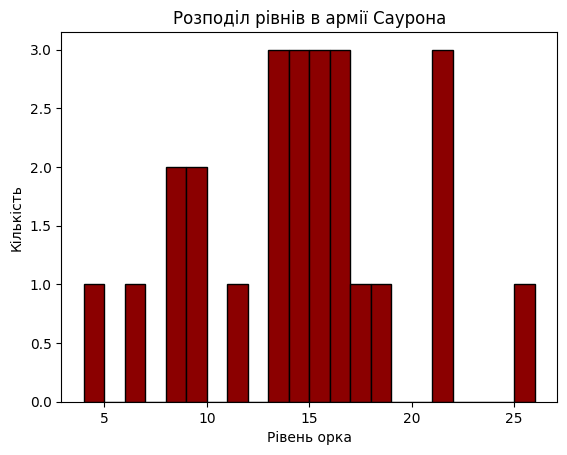

In [5]:
# Симуляція
n_army = 25
player = Player(15)
system = NemesisNarrativeSystem(player)
system.generate_army(n_army)
system.create_relationships()

system.plot_army_hierarchy()
import copy
s_temp = copy.deepcopy(system)

In [6]:
for i in range(10):
    target = random.randint(0, n_army-1)
    system.simulate_battle(target)
    system.simulate_internal_time()

Подія: Бій з Orc-22. Шанс на успіх: 0.77
Результат: Orc-22 вбив вас!
Подія армії: Orc-6 переміг Orc-17 у дуелі та підвищив рівень.
Подія армії: Orc-1 переміг Orc-11 у дуелі та підвищив рівень.
Подія армії: Orc-12 переміг Orc-17 у дуелі та підвищив рівень.
Ефект: Orc-22 отримав підвищення до Lvl 15.
Подія армії: Orc-3 переміг Orc-12 у дуелі та підвищив рівень.
Подія армії: Orc-18 переміг Orc-10 у дуелі та підвищив рівень.
Подія армії: Orc-18 переміг Orc-0 у дуелі та підвищив рівень.
Подія: Бій з Orc-0. Шанс на успіх: 0.23
Результат: Orc-0 вбив вас!
Подія армії: Orc-18 переміг Orc-9 у дуелі та підвищив рівень.
Подія армії: Orc-20 переміг Orc-5 у дуелі та підвищив рівень.
Подія армії: Orc-14 переміг Orc-10 у дуелі та підвищив рівень.
Ефект: Orc-0 отримав підвищення до Lvl 21.
Подія армії: Orc-4 переміг Orc-19 у дуелі та підвищив рівень.
Подія армії: Orc-1 переміг Orc-23 у дуелі та підвищив рівень.
Подія армії: Orc-6 переміг Orc-17 у дуелі та підвищив рівень.
Подія: Бій з Orc-11. Шанс на у

Text(0.5, 1.0, 'Relationship Graph: Player vs Orcs & Orcs Relationships')

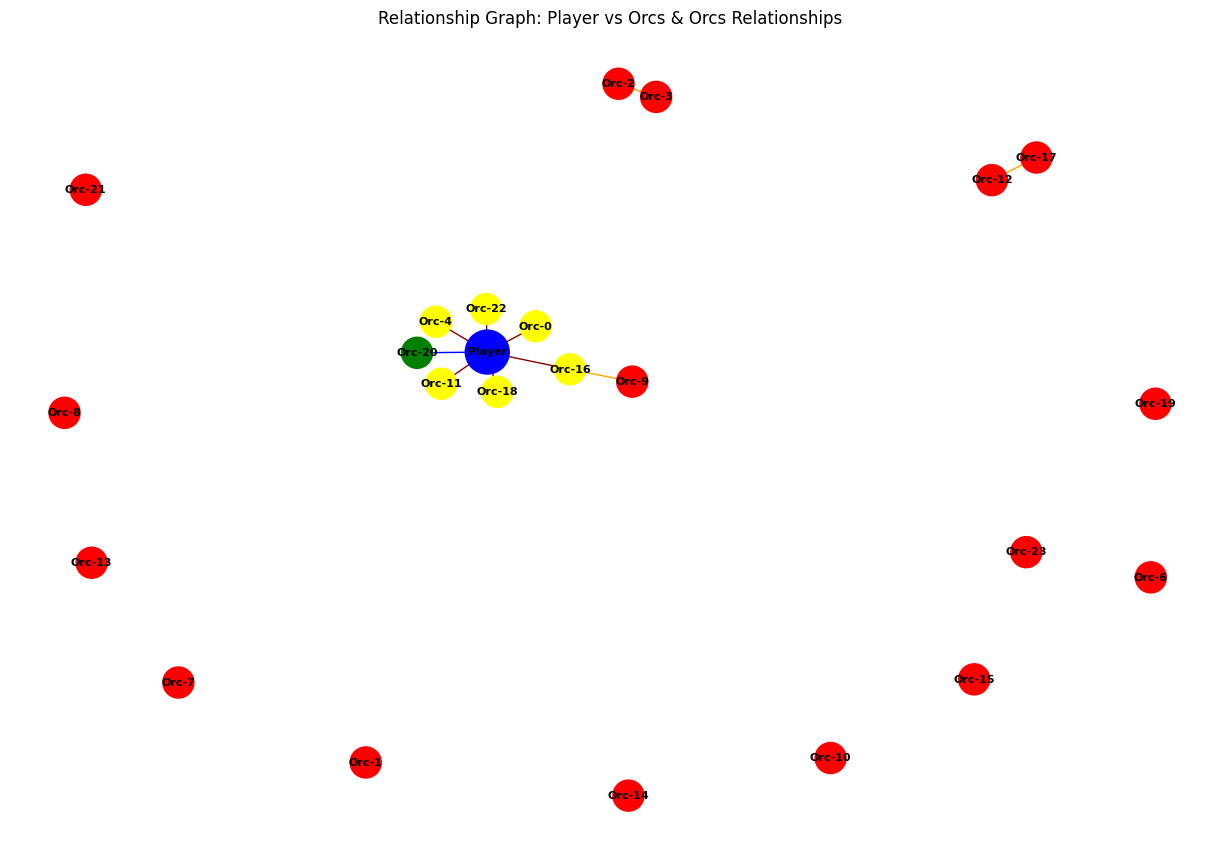

In [ ]:
# Візуалізація
G = nx.Graph()
G.add_node("Player", color='blue', size=1000)

for orc in system.army:
    if orc.is_alive:
        if orc.is_branded:
            node_color = "green"
        elif orc.killed_player:
            node_color = "yellow"
        else:
            node_color = "red"
        
        # if orc.title == "The Survivor":
        #     print(f"{orc.name} is survival")
        
        G.add_node(orc.name, color=node_color, size=500, level=orc.level)
        
        # Relationships
        if orc.blood_brother and orc.blood_brother.is_alive:
            G.add_edge(orc.name, orc.blood_brother.name, type='blood_brother', color='orange')
        
        if orc.is_branded:
            G.add_edge("Player", orc.name, type='branded', color='blue')
        
        if orc.killed_player:
            G.add_edge(orc.name, "Player", type='nemesis', color='darkred')

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

colors = [data['color'] for node, data in G.nodes(data=True)]
sizes = [data['size'] for node, data in G.nodes(data=True)]

edge_colors = [G[u][v].get('color', 'gray') for u, v in G.edges()]

nx.draw(G, pos, with_labels=True, node_color=colors, node_size=sizes, edge_color=edge_colors, font_size=8, font_weight='bold')

plt.title("Relationship Graph: Player vs Orcs & Orcs Relationships")

25


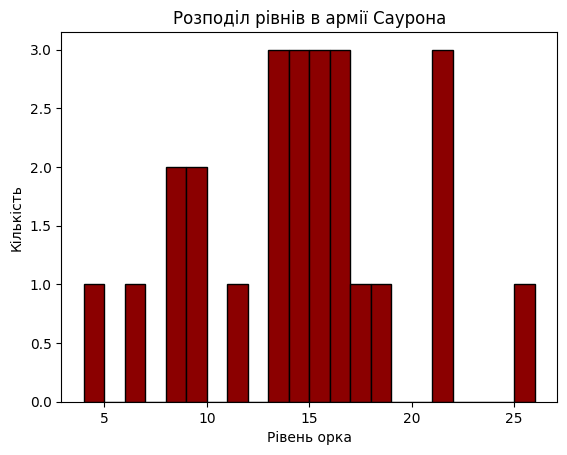

In [8]:
s_temp.plot_army_hierarchy()

23


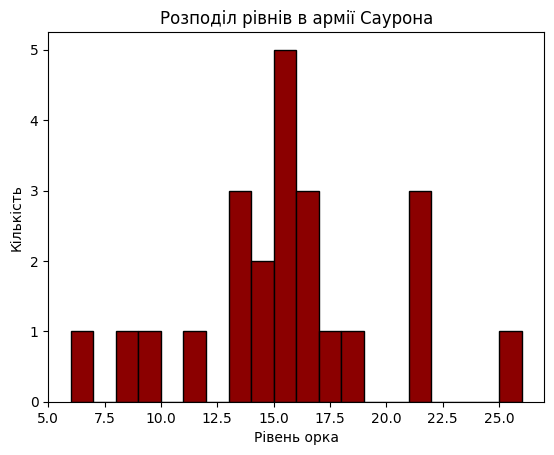

In [9]:
system.plot_army_hierarchy()